In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#crea una variable que va a guardar todo el contenido de mi archivo .csv
#uso doble \\ porque python no interpreta la ruta de manera correcta si uso una sola \
#ya que interpreta saltos de linea y otros comandos.
df = pd.read_csv('churnv2.csv')

#tengo que comprobar si el archivo cargó, para eso usare la funcion head()
#la función head() muestra las primeras 5 filas del archivo
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# información de columnas

In [192]:
#ver numero de filas y columnas, sus nombres y el tipo de dato.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**resumen estadistico**

In [193]:
#ver el resumen estadistico
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


**Contavilizando valores de tipo NAN**

In [194]:
#ver cuantos valores de tipo NAN hay
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Limpieza de datos

In [195]:
import numpy as np

# Reemplazar los espacios en blanco con NaN (valores faltantes)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convertir la columna a un tipo de dato numérico (float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

despues de esto se crearon valores de tipo NAN asi que hay que eliminarlos.

In [196]:
# Eliminar las filas donde TotalCharges es NaN
df = df.dropna(subset=['TotalCharges'])

voy a eliminar la fila customer ID porque no importa en nuestro modelo.

In [197]:
# Eliminar la columna 'customerID' del DataFrame
df = df.drop('customerID', axis=1)

despues de haber eliminado las columnas que no nos servian y los datos NAN toca codificar la columna churn, partner y dependants a una variable discreta.  CHURN = 1 AND 0 = NO


In [198]:
# Convertir 'Yes' a 1 y 'No' a 0 en la columna Churn
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Convertir las otras columnas binarias a 1s y 0s
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)

## One-Hot Encoding


In [199]:
# Lista de columnas categóricas restantes a codificar
columnas_a_codificar = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Aplicar One-Hot Encoding
df = pd.get_dummies(data=df, columns=columnas_a_codificar, drop_first=True)

# El argumento drop_first=True evita un problema estadístico llamado multicolinealidad,
# que es cuando una columna se puede predecir a partir de otras.
# En este caso, si ya tienes las columnas 'InternetService_DSL' e 'InternetService_Fiber optic',
# la columna 'InternetService_No' es redundante.

parametrizo la columna phone service

In [200]:
# Convertir la columna 'PhoneService' a int, ya que es binaria
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)

# Proceso de analisis

In [201]:
tasa_general_abandono = df['Churn'].mean() * 100
print(f"La tasa general de abandono es de: {tasa_general_abandono:.2f}%")

La tasa general de abandono es de: 26.58%


In [202]:
# Tasa de abandono para clientes con Fibra Óptica
tasa_fibra = df[df['InternetService_Fiber optic'] == True]['Churn'].mean() * 100
print(f"La tasa de abandono para clientes con Fibra Óptica es de: {tasa_fibra:.2f}%")

# Tasa de abandono para clientes con DSL
tasa_dsl = df[df['InternetService_No'] == False]['Churn'].mean() * 100
print(f"La tasa de abandono para clientes con DSL es de: {tasa_dsl:.2f}%")

La tasa de abandono para clientes con Fibra Óptica es de: 41.89%
La tasa de abandono para clientes con DSL es de: 31.86%


In [203]:
promedios_por_abandono = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
print("\nPromedios de variables numéricas por estado de abandono:")
print(promedios_por_abandono)


Promedios de variables numéricas por estado de abandono:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
0      37.650010       61.307408   2555.344141
1      17.979133       74.441332   1531.796094


In [204]:
clientes_electronic_check = df[df['PaymentMethod_Electronic check'] == True]
conteo_abandono_electronico = clientes_electronic_check['Churn'].value_counts()
print("\nConteo de clientes con 'Electronic check' (0 = No, 1 = Sí):")
print(conteo_abandono_electronico)


Conteo de clientes con 'Electronic check' (0 = No, 1 = Sí):
Churn
0    1294
1    1071
Name: count, dtype: int64


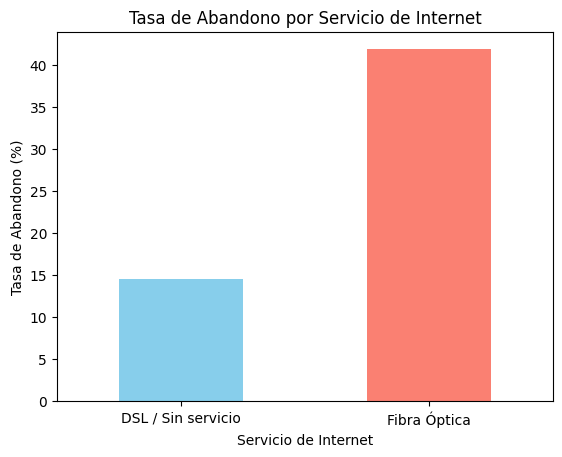

In [205]:
import matplotlib.pyplot as plt

tasa_abandono = df.groupby('InternetService_Fiber optic')['Churn'].mean() * 100
tasa_abandono_con_nombres = tasa_abandono.rename({True: 'Fibra Óptica', False: 'DSL / Sin servicio'})

# Crear la gráfica
tasa_abandono_con_nombres.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Tasa de Abandono por Servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Tasa de Abandono (%)')
plt.xticks(rotation=0)
plt.show()

usaremos el method value count para medir la tasa de abandono general y porcentajes , en  3 categorias , general , señior y parejas.  

In [206]:

churn_count=df['Churn'].value_counts() #how many clients with churn
churn_percentages = df['Churn'].value_counts(normalize=True) * 100 # percentages
print(f"churn count: {churn_count} percentages : {churn_percentages}")

churn count: Churn
0    5163
1    1869
Name: count, dtype: int64 percentages : Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


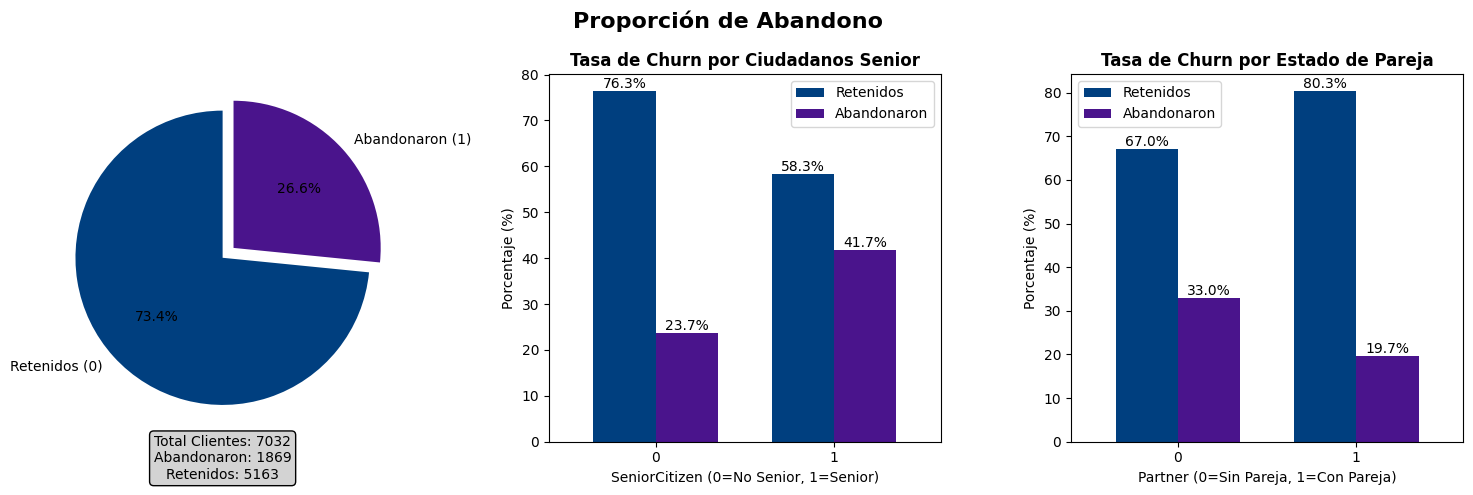

In [207]:
#GRAPH 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Proporción de Abandono', fontsize=16, fontweight='bold')
colors = ['#003f7f', '#4a148c']
labels = ['Retenidos (0)', 'Abandonaron (1)'] #labels for pie
wedges, texts, autotexts = ax1.pie(
        churn_count.values,    # numerical values
        labels=labels,          # Etiquetas ['Retenidos (0)', 'Abandonaron (1)']
        autopct='%1.1f%%',      # Formato de porcentaje con 1 decimal
        colors=colors,          # Colores personalizados
        startangle=90,          # Empezar desde las 12 en punto (90 grados)
        explode=(0, 0.1)        # Separar el segmento de churn (segundo elemento)
    )                           #[0] churn and [1] current clients
info_text = f'Total Clientes: {len(df)}\nAbandonaron: {churn_count[1]}\nRetenidos: {churn_count[0]}'
ax1.text(0, -1.5,           # Posición: centro horizontal (0), abajo (-1.5)
info_text,
ha='center',        # Alineación horizontal centrada
fontsize=10,
bbox=dict(boxstyle="round,pad=0.3",    # Caja redondeada con padding
facecolor="lightgray"))       # Color de fondo gris claro

#-------------------------------------------------------------------------------------
senior_churn = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
                #groub by [sn and churn] i mean categories
senior_churn_pct = senior_churn.div(senior_churn.sum(axis=1), axis=0) * 100
senior_churn_pct.plot(kind='bar', ax=ax2, color=colors, width=0.7)

ax2.set_title('Tasa de Churn por Ciudadanos Senior', fontweight='bold')
ax2.set_xlabel('SeniorCitizen (0=No Senior, 1=Senior)')
ax2.set_ylabel('Porcentaje (%)')
ax2.legend(['Retenidos', 'Abandonaron'])
ax2.tick_params(axis='x', rotation=0) # Rotar etiquetas del eje X

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%')
#-------------------------------------------------------------------------------
partner_churn = df.groupby(['Partner', 'Churn']).size().unstack(fill_value=0)
partner_churn_pct = partner_churn.div(partner_churn.sum(axis=1), axis=0) * 100
    
partner_churn_pct.plot(kind='bar', ax=ax3, color=colors, width=0.7)
ax3.set_title('Tasa de Churn por Estado de Pareja', fontweight='bold')
ax3.set_xlabel('Partner (0=Sin Pareja, 1=Con Pareja)')
ax3.set_ylabel('Porcentaje (%)')
ax3.legend(['Retenidos', 'Abandonaron'])
ax3.tick_params(axis='x', rotation=0)

# Etiquetas de valores
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()
#-------------------------------------------    

                

GRAFICAS DE PROPORCIONES DE CHURN 





TOTAL CLIENTES :7032 
CHURN : 1869
RETENIDOS: 5163             

In [208]:
# Guarda el DataFrame 'df' en un nuevo archivo CSV
# 'index=False' es importante para no guardar la columna del índice como una columna extra
df.to_csv('datos_limpios.csv', index=False)